In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


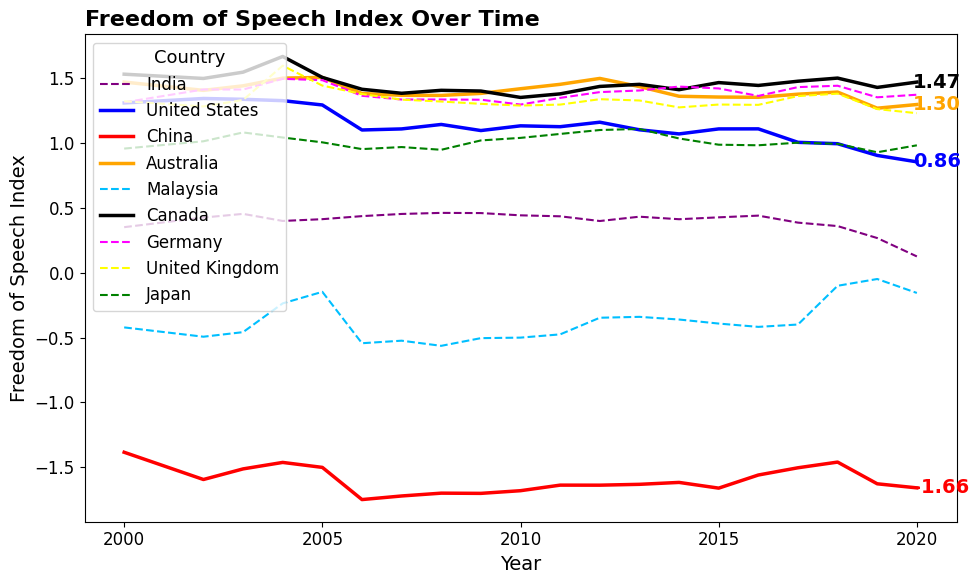

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'legend.title_fontsize': 13
})

plt.figure(figsize=(10, 6))

file_path = 'Institutional_data_full.csv'
data1 = pd.read_csv(file_path)

# Convert to numeric
data1['Voice_and_Accountability'] = pd.to_numeric(
    data1['Voice_and_Accountability'], errors='coerce'
)

filtered_df = data1[(data1['Year'] >= 2000) & (data1['Year'] <= 2020)]

selected_countries = ["India", "United States", "China", "Australia", "Malaysia", "Canada", "Germany", "United Kingdom","Japan"]

# Define colors for highlighted countries
highlighted_countries = {
    "United States": "blue", 
    "Australia": "orange", 
    "China": "red", 
    "Canada": "black"
}
bright_colors = ["purple","deepskyblue", "fuchsia","yellow", "green"]  # Colors for other countries
color_index = 0

for country in selected_countries:
    df_country = filtered_df[filtered_df['Country'] == country]
    if country in highlighted_countries:
        plt.plot(
            df_country['Year'],
            df_country['Voice_and_Accountability'],
            label=country,
            linewidth=2.5,
            color=highlighted_countries[country]
        )
        latest_year = df_country['Year'].iloc[-1]
        latest_value = df_country['Voice_and_Accountability'].iloc[-1]

        if pd.notna(latest_value):
            plt.text(
                latest_year-0.1,
                latest_value,
                f'{latest_value:.2f}',
                fontsize=14,  # Medium annotation
                weight='bold',
                color=highlighted_countries[country],
                va='center'
            )
    else:
        plt.plot(
            df_country['Year'],
            df_country['Voice_and_Accountability'],
            label=country,
            linewidth=1.5,
            linestyle='--',
            color=bright_colors[color_index]
        )
        color_index = (color_index + 1) % len(bright_colors)

plt.xlabel('Year')
plt.ylabel('Freedom of Speech Index')
plt.title('Freedom of Speech Index Over Time', weight='bold', ha='left', x=0)
plt.xticks(range(2000, 2022, 5))
plt.legend(title="Country", loc='upper left')

plt.tight_layout()
plt.savefig('freedom_of_speech_index.png', dpi=300, bbox_inches='tight')
plt.show()
